In [1]:
"""
Predicción de Diabetes en Pacientes
Trabajo Práctico Final - Python para Ciencia de Datos

Objetivo:
Dado el perfil médico de una paciente, predecir si tiene diabetes o no mediante
un modelo de clasificación binaria.

Dataset: Pima Indians Diabetes Database (Kaggle)
- 768 filas, 9 columnas
- 8 características médicas
- 1 variable objetivo (Outcome): 0 = sin diabetes, 1 = con diabetes
"""

'\nPredicción de Diabetes en Pacientes\nTrabajo Práctico Final - Python para Ciencia de Datos\n\nObjetivo:\nDado el perfil médico de una paciente, predecir si tiene diabetes o no mediante\nun modelo de clasificación binaria.\n\nDataset: Pima Indians Diabetes Database (Kaggle)\n- 768 filas, 9 columnas\n- 8 características médicas\n- 1 variable objetivo (Outcome): 0 = sin diabetes, 1 = con diabetes\n'

In [2]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
columnas_sospechosas = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for columna in columnas_sospechosas:
    cantidad_ceros = (df[columna] == 0).sum()
    porcentaje = (cantidad_ceros / len(df)) * 100
    print(f"{columna}: {cantidad_ceros} ceros ({porcentaje:.1f}%)")

Glucose: 5 ceros (0.7%)
BloodPressure: 35 ceros (4.6%)
SkinThickness: 227 ceros (29.6%)
Insulin: 374 ceros (48.7%)
BMI: 11 ceros (1.4%)


In [7]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

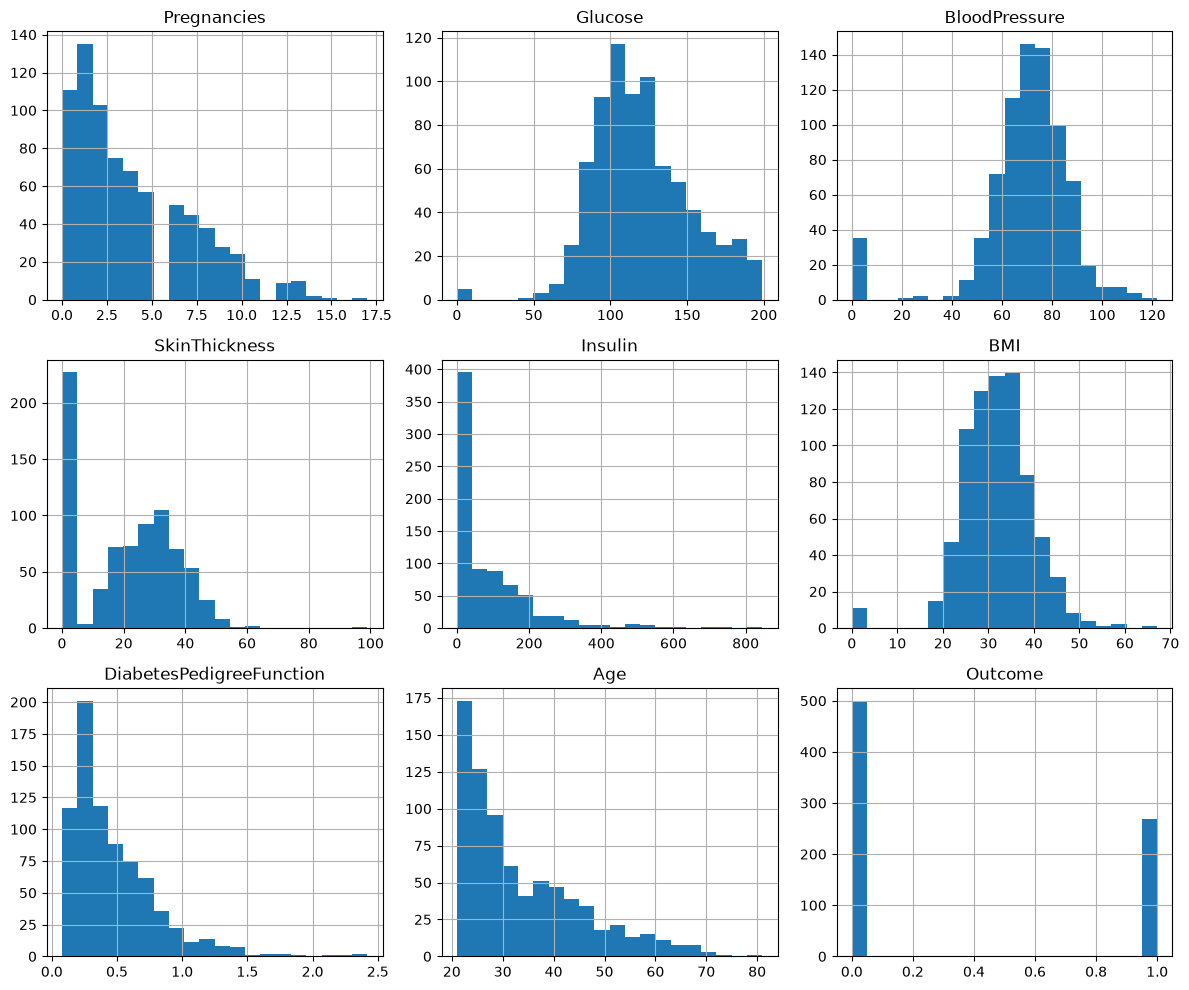

In [9]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

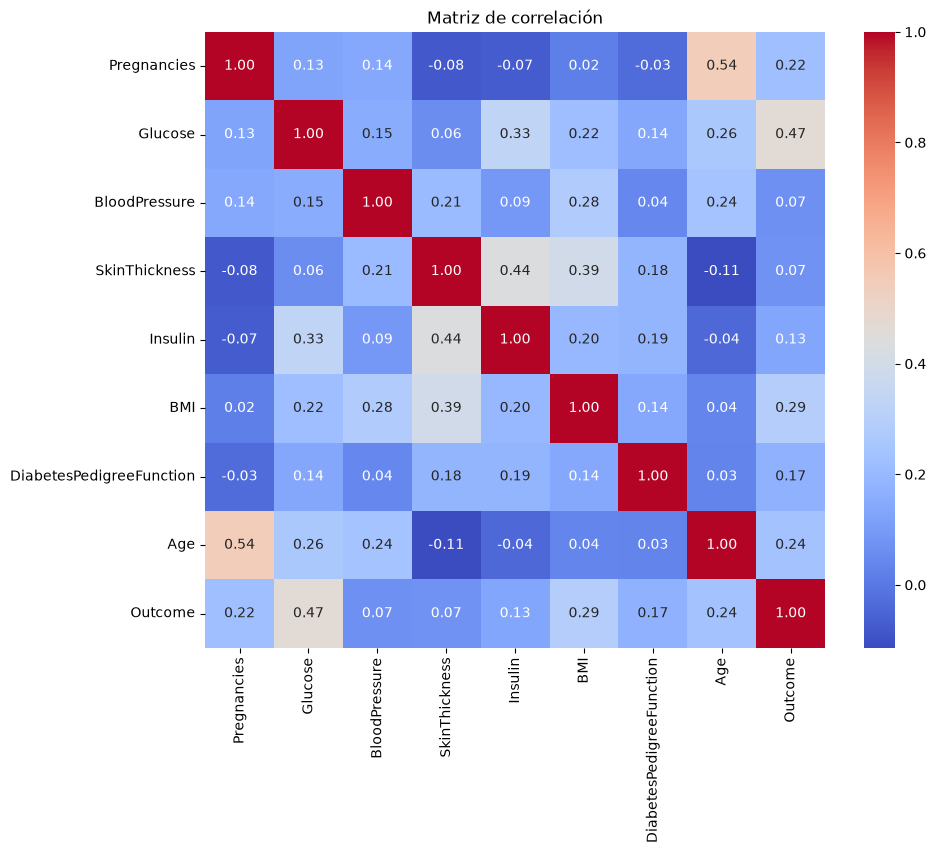

In [10]:
plt.figure(figsize=(10, 8))
correlacion = df.corr()
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

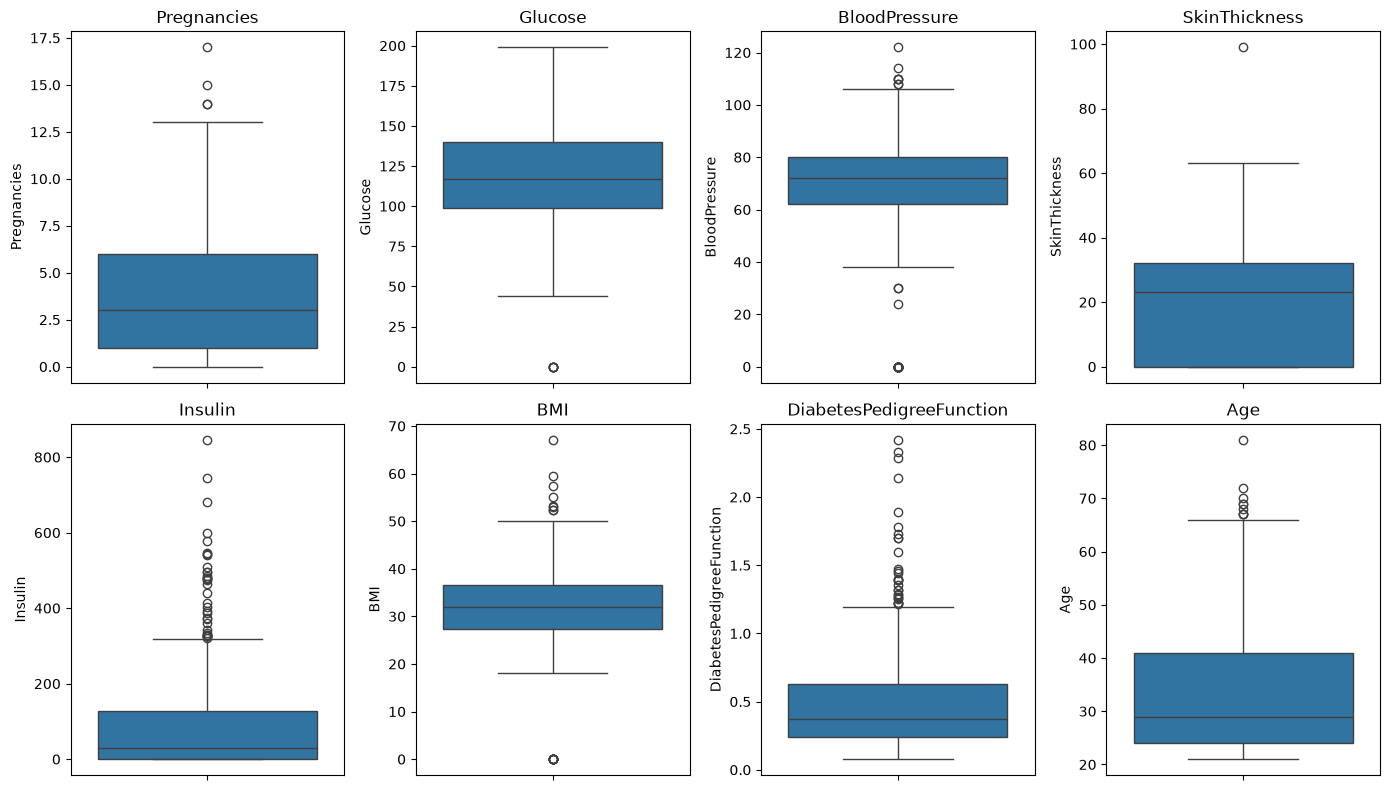

In [11]:
columnas_numericas = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

plt.figure(figsize=(14, 8))
for i, columna in enumerate(columnas_numericas, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[columna])
    plt.title(columna)

plt.tight_layout()
plt.show()

In [12]:
"""
PREPROCESAMIENTO

Convertimos los ceros médicamente imposibles en valores nulos (NaN)
y luego los imputamos usando la mediana del grupo según si la paciente tiene diabetes.
"""

'\nPREPROCESAMIENTO\n\nConvertimos los ceros médicamente imposibles en valores nulos (NaN)\ny luego los imputamos usando la mediana del grupo según si la paciente tiene diabetes.\n'

In [13]:
import numpy as np

columnas_a_corregir = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for columna in columnas_a_corregir:
    df[columna] = df[columna].replace(0, np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [14]:
columnas_a_imputar = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for columna in columnas_a_imputar:
    mediana_por_grupo = df.groupby("Outcome")[columna].median()
    df[columna] = df[columna].fillna(df["Outcome"].map(mediana_por_grupo))

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
"""
SEPARACIÓN DE DATOS: Características (X) y Etiqueta (y)

Separamos las variables predictivas de la etiqueta objetivo.
"""

'\nSEPARACIÓN DE DATOS: Características (X) y Etiqueta (y)\n\nSeparamos las variables predictivas de la etiqueta objetivo.\n'

In [16]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (614, 8)
Test: (154, 8)


In [18]:
"""
ESTANDARIZACIÓN

La Regresión Logística requiere que las variables estén estandarizadas
(media=0, desviación estándar=1). El Árbol de Decisión no la necesita.
"""

'\nESTANDARIZACIÓN\n\nLa Regresión Logística requiere que las variables estén estandarizadas\n(media=0, desviación estándar=1). El Árbol de Decisión no la necesita.\n'

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
"""
MODELADO

REGRESIÓN LOGÍSTICA
Se entrena con datos estandarizados ya que este modelo es sensible a la escala.
"""

'\nMODELADO\n\nREGRESIÓN LOGÍSTICA\nSe entrena con datos estandarizados ya que este modelo es sensible a la escala.\n'

In [21]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, classification_report

y_pred_logistico = modelo_logistico.predict(X_test_scaled)

accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
print(f"Accuracy: {accuracy_logistico:.4f}")

recall_logistico = recall_score(y_test, y_pred_logistico)
print(f"Recall: {recall_logistico:.4f}")

print("\n", classification_report(y_test, y_pred_logistico))

Accuracy: 0.7078
Recall: 0.5556

               precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



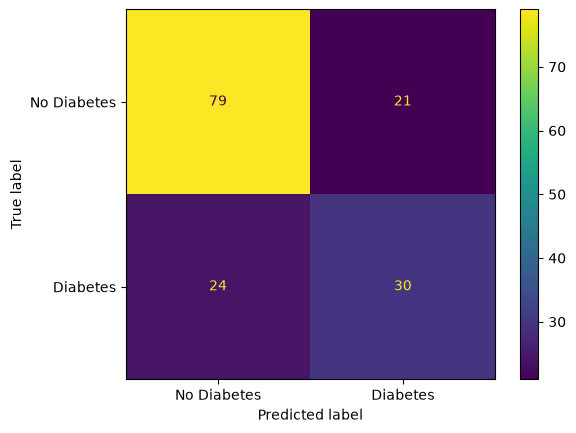

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, 
    y_pred=y_pred_logistico, 
    display_labels=["No Diabetes", "Diabetes"]
)

In [24]:
"""
ÁRBOL DE DECISIÓN

Probamos tres configuraciones: sin poda, con pre-poda y con post-poda.

Árbol sin poda (línea base)
Observaremos el comportamiento natural del árbol, que tiende al overfitting.
"""

'\nÁRBOL DE DECISIÓN\n\nProbamos tres configuraciones: sin poda, con pre-poda y con post-poda.\n\nÁrbol sin poda (línea base)\nObservaremos el comportamiento natural del árbol, que tiende al overfitting.\n'

In [25]:
from sklearn.tree import DecisionTreeClassifier

arbol_sin_poda = DecisionTreeClassifier(random_state=42)
arbol_sin_poda.fit(X_train, y_train)

y_pred_train = arbol_sin_poda.predict(X_train)
y_pred_test = arbol_sin_poda.predict(X_test)

print(f"Accuracy en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy en TEST:  {accuracy_score(y_test, y_pred_test):.4f}")

Accuracy en TRAIN: 1.0000
Accuracy en TEST:  0.8117


In [26]:
"""
Árbol con Pre-Poda
Limitamos el crecimiento del árbol desde el inicio con max_depth, min_samples_split y min_samples_leaf.
"""

'\nÁrbol con Pre-Poda\nLimitamos el crecimiento del árbol desde el inicio con max_depth, min_samples_split y min_samples_leaf.\n'

In [27]:
arbol_pre_poda = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
arbol_pre_poda.fit(X_train, y_train)

y_pred_train = arbol_pre_poda.predict(X_train)
y_pred_test = arbol_pre_poda.predict(X_test)

print(f"Accuracy en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy en TEST:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Recall en TEST: {recall_score(y_test, y_pred_test):.4f}")

Accuracy en TRAIN: 0.9088
Accuracy en TEST:  0.8701
Recall en TEST: 0.7963


In [28]:
"""
Árbol con Post-Poda
Dejamos crecer el árbol completamente y luego lo podamos usando ccp_alpha,
que penaliza la complejidad.
"""

'\nÁrbol con Post-Poda\nDejamos crecer el árbol completamente y luego lo podamos usando ccp_alpha,\nque penaliza la complejidad.\n'

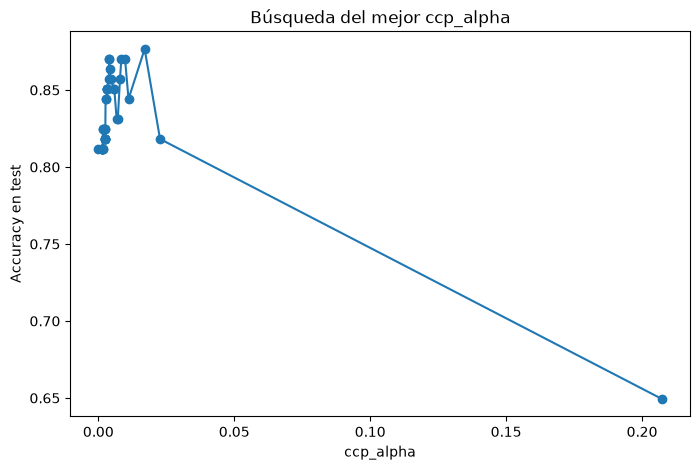

Mejor ccp_alpha encontrado: 0.01703


In [29]:
arbol_completo = DecisionTreeClassifier(random_state=42)
path = arbol_completo.cost_complexity_pruning_path(X_train, y_train)
valores_alpha = path.ccp_alphas

accuracies_test = []
for alpha in valores_alpha:
    arbol_temp = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    arbol_temp.fit(X_train, y_train)
    accuracies_test.append(accuracy_score(y_test, arbol_temp.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(valores_alpha, accuracies_test, marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy en test")
plt.title("Búsqueda del mejor ccp_alpha")
plt.show()

mejor_alpha = valores_alpha[accuracies_test.index(max(accuracies_test))]
print(f"Mejor ccp_alpha encontrado: {mejor_alpha:.5f}")

In [30]:
arbol_post_poda = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01703)
arbol_post_poda.fit(X_train, y_train)

y_pred_train = arbol_post_poda.predict(X_train)
y_pred_test = arbol_post_poda.predict(X_test)

print(f"Accuracy en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy en TEST:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Recall en TEST: {recall_score(y_test, y_pred_test):.4f}")

Accuracy en TRAIN: 0.8404
Accuracy en TEST:  0.8766
Recall en TEST: 0.7037


In [31]:
"""
EXPORTACIÓN DEL MODELO FINAL

Guardamos el Árbol de Decisión con Pre-Poda en un archivo .pkl
para usarlo en el backend (FastAPI).
"""

'\nEXPORTACIÓN DEL MODELO FINAL\n\nGuardamos el Árbol de Decisión con Pre-Poda en un archivo .pkl\npara usarlo en el backend (FastAPI).\n'

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(arbol_pre_poda, "models/modelo_diabetes.pkl")

print("Modelo exportado correctamente en models/modelo_diabetes.pkl")

Modelo exportado correctamente en models/modelo_diabetes.pkl
